In [27]:
import sys
import os
import numpy as np
import mne
import matplotlib.pyplot as plt

# Add the project root to the Python path
project_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, project_root)

from src.data_handling.preprocessing_utils import load_gdf_file

In [28]:
# Load raw data
raw_filepath = os.path.join(project_root, 'data', 'A01T.gdf')
raw, _, _ = load_gdf_file(raw_filepath)

# Rename channels to match standard 10-20 montage
ch_names_mapping = {
    'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4', 'EEG-5': 'C5',
    'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4', 'EEG-8': 'C6', 'EEG-9': 'CP3',
    'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4', 'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'
}
raw.rename_channels(ch_names_mapping)
raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})

# Load preprocessed data
preprocessed_filepath = os.path.join(project_root, 'data', 'preprocessed', 'A01T_epochs.npy')
preprocessed_epochs = np.load(preprocessed_filepath)

preprocessed_labels_filepath = os.path.join(project_root, 'data', 'preprocessed', 'A01T_labels.npy')
preprocessed_labels = np.load(preprocessed_labels_filepath)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']


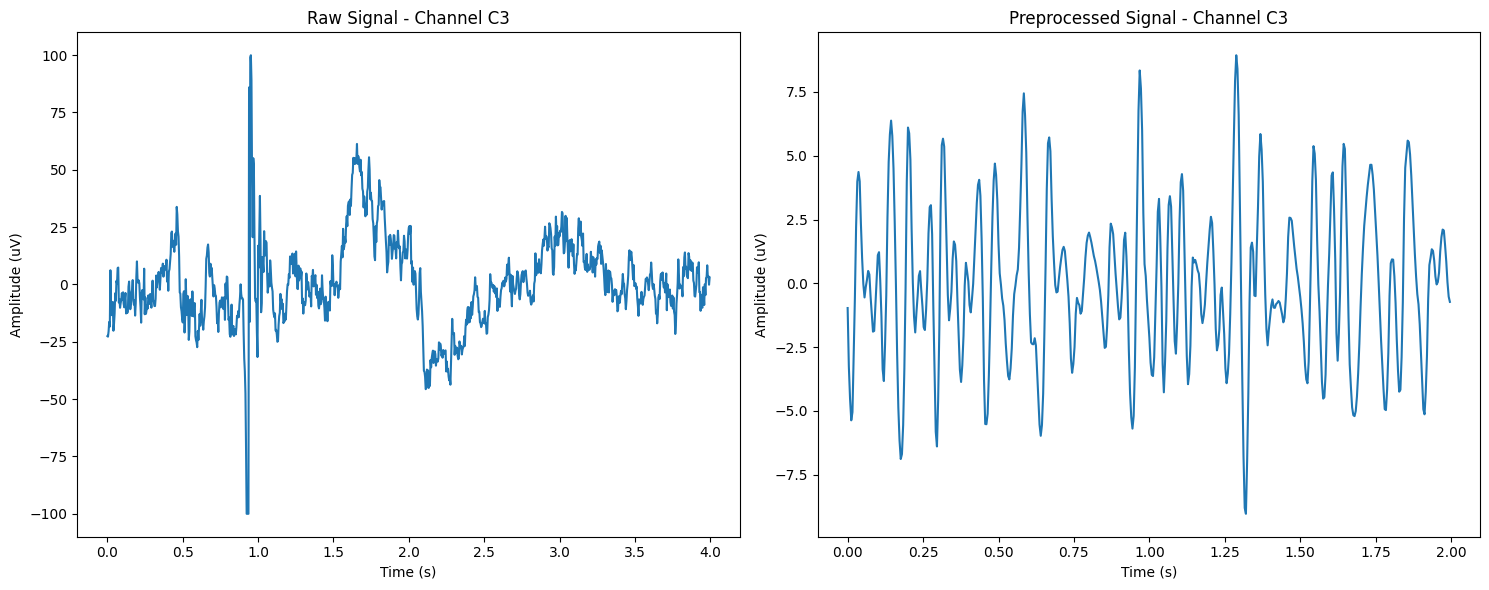

In [29]:
# Plot raw vs. preprocessed signal for one channel
channel_to_plot = 'C3'
channel_index = raw.ch_names.index(channel_to_plot)

raw_data, times = raw[channel_index, :1000]

# Get a single epoch of preprocessed data for the same channel
preprocessed_data = preprocessed_epochs[0, channel_index, :]
preprocessed_times = np.arange(preprocessed_data.shape[0]) / raw.info['sfreq']

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(times, raw_data.T)
plt.title(f'Raw Signal - Channel {channel_to_plot}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')

plt.subplot(1, 2, 2)
plt.plot(preprocessed_times, preprocessed_data.T)
plt.title(f'Preprocessed Signal - Channel {channel_to_plot}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')

plt.tight_layout()
plt.show()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Not setting metadata
273 matching events found
No baseline correction applied
0 projection items activated
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


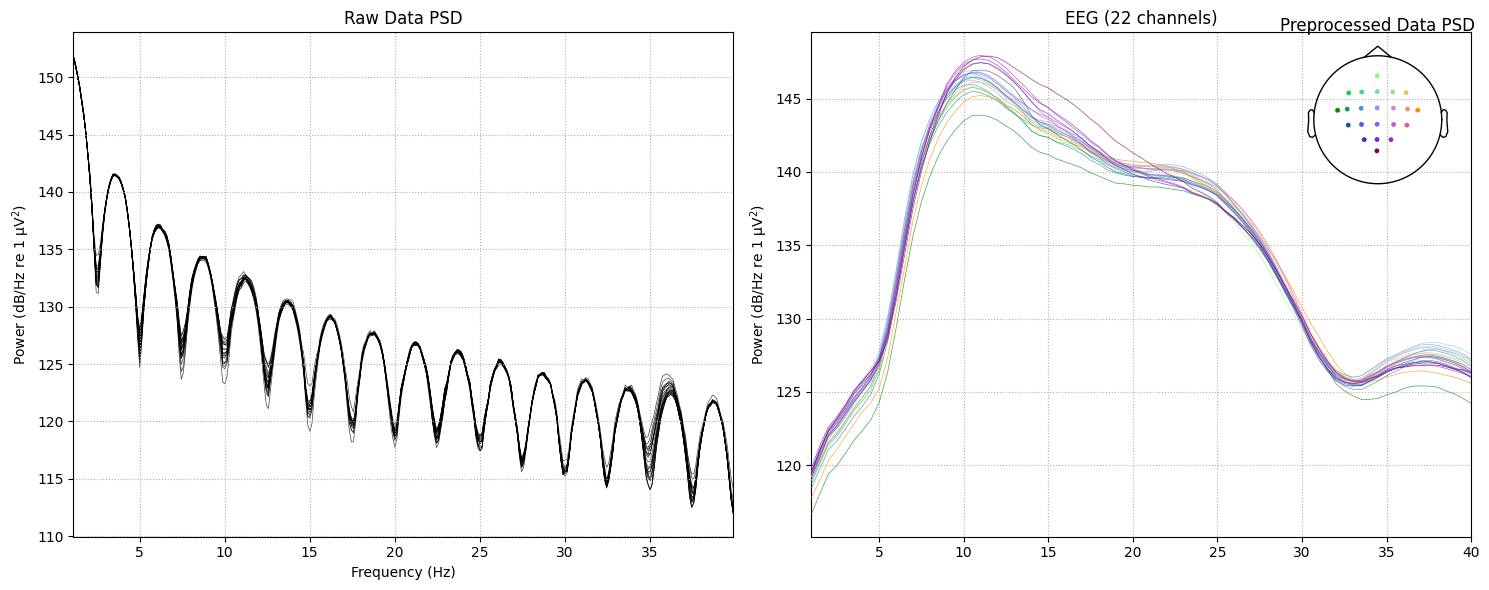

In [30]:
# Plot PSD of raw and preprocessed data
plt.figure(figsize=(15, 6))

# Raw data PSD
raw.plot_psd(ax=plt.subplot(1, 2, 1), show=False, fmin=1, fmax=40)
plt.title('Raw Data PSD')

# Preprocessed data PSD
# To plot the PSD of the epoched data, we need to create an MNE Epochs object
eeg_channels = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
ch_names = [raw.ch_names[i] for i in eeg_channels]
ch_types = ['eeg'] * len(ch_names)
sfreq = raw.info['sfreq']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)
epochs = mne.EpochsArray(preprocessed_epochs, info)

epochs.plot_psd(ax=plt.subplot(1, 2, 2), show=False, fmin=1, fmax=40)
plt.title('Preprocessed Data PSD')

plt.tight_layout()
plt.show()

Not setting metadata
273 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


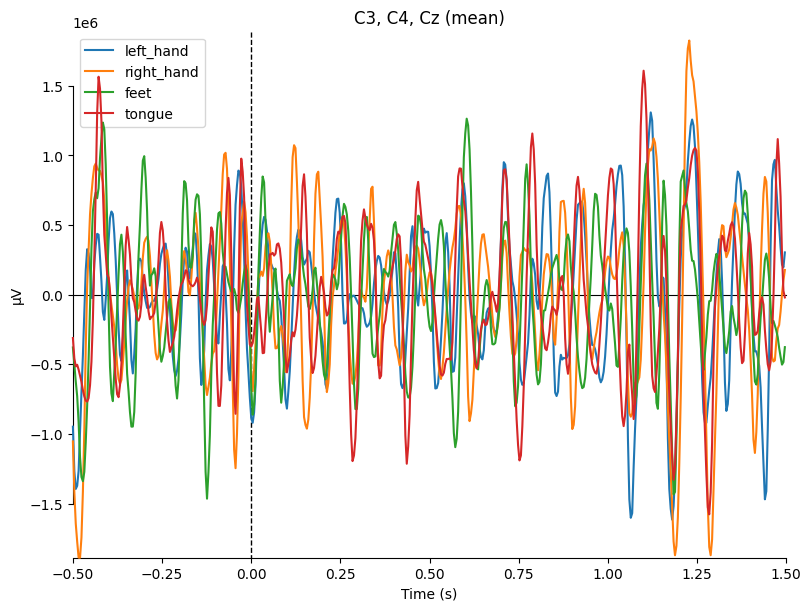

In [31]:
# Create an MNE Epochs object from the preprocessed data
eeg_channels = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
ch_names = [raw.ch_names[i] for i in eeg_channels]
ch_types = ['eeg'] * len(ch_names)
sfreq = raw.info['sfreq']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)
epochs = mne.EpochsArray(preprocessed_epochs, info, tmin=-0.5)

# Create a mapping from label value to class name
event_id = {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}

# Create an events array for the epochs object
events = np.array([np.arange(len(preprocessed_labels)),
                   np.zeros(len(preprocessed_labels), dtype=int),
                   preprocessed_labels]).T

epochs.events = events
epochs.event_id = event_id

# Plot evoked responses for each class
evokeds = {class_name: epochs[class_name].average() for class_name in event_id.keys()}
mne.viz.plot_compare_evokeds(evokeds, picks=['C3', 'C4', 'Cz'], combine='mean')
plt.show()

Not setting metadata
273 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...
converting legacy list-of-tuples input to a dict for the `bands` parameter
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...
converting legacy list-of-tuples input to a dict for the `bands` parameter


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

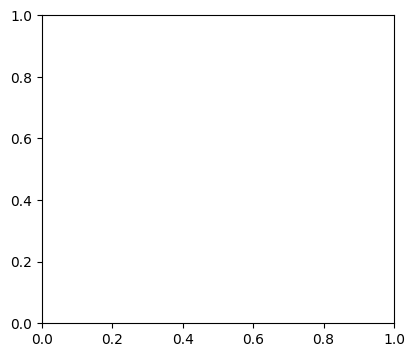

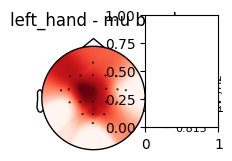

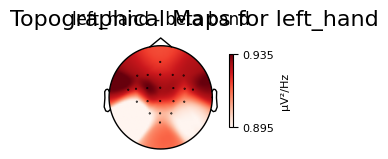

In [32]:
# Plot topographical maps of power
freq_bands = {'mu': (8, 12), 'beta': (13, 30)}

# Create an MNE Epochs object with montage info
eeg_channels = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
ch_names = [raw.ch_names[i] for i in eeg_channels]
ch_types = ['eeg'] * len(ch_names)
sfreq = raw.info['sfreq']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)
epochs_with_montage = mne.EpochsArray(preprocessed_epochs, info, tmin=-0.5)
events = np.array([np.arange(len(preprocessed_labels)),
                   np.zeros(len(preprocessed_labels), dtype=int),
                   preprocessed_labels]).T
epochs_with_montage.events = events
epochs_with_montage.event_id = event_id

for class_name in event_id.keys():
    plt.figure(figsize=(10, 4))
    for i, (band_name, (fmin, fmax)) in enumerate(freq_bands.items()):
        plt.subplot(1, 2, i + 1)
        power = epochs_with_montage[class_name].compute_psd(fmin=fmin, fmax=fmax)
        power.plot_topomap(ch_type='eeg', bands=[(fmin, fmax, band_name)], normalize=True, contours=0, show=False)
        plt.title(f'{class_name} - {band_name} band')
    plt.suptitle(f'Topographical Maps for {class_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()